In [1]:
from scipy.optimize import minimize
import scipy.stats as stats
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
tb1 = pd.read_excel('regcar.xlsx')
tb1

,TV Ads,car Sold
0,1,14
1,3,24
2,2,18
3,1,17
4,3,27


In [3]:
import statsmodels.api as sm
x = tb1['TV Ads']
y = tb1['car Sold']
x2 = sm.add_constant(x)
mod1 = sm.OLS(y, x2)
modl2 = mod1.fit()
print(modl2.summary())

                            OLS Regression Results                            
Dep. Variable:               car Sold   R-squared:                       0.877
Model:                            OLS   Adj. R-squared:                  0.836
Method:                 Least Squares   F-statistic:                     21.43
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0190
Time:                        00:51:26   Log-Likelihood:                -9.6687
No. Observations:                   5   AIC:                             23.34
Df Residuals:                       3   BIC:                             22.56
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.0000      2.366      4.226      0.0

C:\Users\vashi\anaconda3\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [4]:
e = modl2.resid

In [5]:
e

0   -1.0
1   -1.0
2   -2.0
3    2.0
4    2.0
dtype: float64

In [6]:
np.std(e)

1.6733200530681513

In [7]:
def lik(parameters):
    m = parameters[0]
    b = parameters[1]
    sigma = parameters[2]
    for i in np.arange(0, len(x)):
        y_exp = m * x + b
    L = (len(x)/2 * np.log(2 * np.pi) + len(x)/2 * np.log(sigma ** 2) + 1 / 
          (2 * sigma ** 2) * sum((y - y_exp) ** 2))
    return L

In [8]:
lik_model = minimize(lik, np.array([5,5,5]), method = 'Nelder-Mead')

In [9]:
lik_model.x

array([ 4.99997913, 10.00006001,  1.67332791])

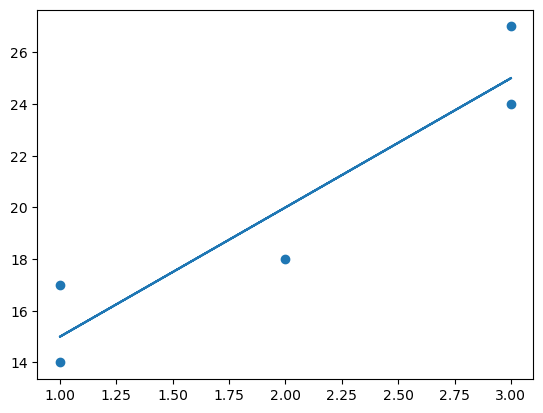

In [10]:
plt.scatter(x,y)
plt.plot(x, lik_model['x'][0] * x + lik_model['x'][1])
plt.show()

In [11]:
minimize?

Signature:
minimize(
    fun,
    x0,
    args=(),
    method=None,
    jac=None,
    hess=None,
    hessp=None,
    bounds=None,
    constraints=(),
    tol=None,
    callback=None,
    options=None,
)
Docstring:
Minimization of scalar function of one or more variables.

Parameters
----------
fun : callable
    The objective function to be minimized::

        fun(x, *args) -> float

    where ``x`` is a 1-D array with shape (n,) and ``args``
    is a tuple of the fixed parameters needed to completely
    specify the function.

    Suppose the callable has signature ``f0(x, *my_args, **my_kwargs)``, where
    ``my_args`` and ``my_kwargs`` are required positional and keyword arguments.
    Rather than passing ``f0`` as the callable, wrap it to accept
    only ``x``; e.g., pass ``fun=lambda x: f0(x, *my_args, **my_kwargs)`` as the
    callable, where ``my_args`` (tuple) and ``my_kwargs`` (dict) have been
    gathered before invoking this function.
x0 : ndarray, shape (n,)
    Initial gu